# Module 2.1 — 2D Scalar Transport

**The bridge from Module 1 to the full N-S solver:**
Everything in Module 1 was 1D. Real flows are 2D or 3D. This module extends the advection-diffusion equation to two dimensions — not by introducing new physics, but by adding a second spatial direction. Once you can think clearly about 2D indexing and boundary conditions, the jump to Navier-Stokes (Module 2.3) is straightforward.

**The equation:**
$$\frac{\partial u}{\partial t} + c_x \frac{\partial u}{\partial x} + c_y \frac{\partial u}{\partial y} = \alpha\left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}\right)$$

A scalar quantity (temperature, dye concentration, a pollutant) is transported by a known 2D velocity field $(c_x, c_y)$ and diffuses isotropically.

**Roadmap:**
1. The 2D indexing convention — the most common source of bugs
2. Extension of 1D stencils to 2D — nothing new, just a second dimension
3. The 2D CFL condition — how both velocity components constrain the time step
4. Operator splitting — using 1D solvers as 2D building blocks
5. Boundary conditions on all four sides
6. Implementation and validation against analytical solution

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. The 2D Indexing Convention — Read This Before Writing Any 2D Code

### The mental model

A 2D field is stored as a matrix `u[j, i]`:
- `j` is the **row index** → maps to the **y direction** (axis 0, vertical)
- `i` is the **column index** → maps to the **x direction** (axis 1, horizontal)

```
Physical domain:           Array layout u[j, i]:

y ↑                        j=ny-1  [row ny-1: top boundary]
  │  u(x, y)               j=3     [row 3              ]
  │                         j=2     [row 2              ]
  └──────────→ x            j=1     [row 1              ]
                             j=0     [row 0: bottom boundary]
                                      i=0  i=1  ...  i=nx-1
                                      (left)           (right)
```

**Why j first, not i?** NumPy arrays are stored row by row (C order). The outer index (j) changes more slowly — it's the y coordinate. The inner index (i) changes fastest — it's the x coordinate. This matches how you read a matrix: row first, then column.

### The neighbour table — memorise it

For an interior cell `u[j, i]`:

| Direction | Physical meaning | Array expression |
|-----------|-----------------|------------------|
| Right neighbour | $u_{j, i+1}$ | `u[j, 2:]` (when j=1:-1) |
| Left neighbour | $u_{j, i-1}$ | `u[j, :-2]` |
| Top neighbour | $u_{j+1, i}$ | `u[2:, i]` (when i=1:-1) |
| Bottom neighbour | $u_{j-1, i}$ | `u[:-2, i]` |

In fully vectorised form for all interior cells at once:

```python
# Right: u[j, i+1]
u[1:-1, 2:]
# Left:  u[j, i-1]
u[1:-1, :-2]
# Top:   u[j+1, i]
u[2:, 1:-1]
# Bottom: u[j-1, i]
u[:-2, 1:-1]
# Centre: u[j, i]
u[1:-1, 1:-1]
```

**The 2D Laplacian — the single most important 2D stencil:**

$$\nabla^2 u = \frac{u_{j,i+1}-2u_{j,i}+u_{j,i-1}}{\Delta x^2} + \frac{u_{j+1,i}-2u_{j,i}+u_{j-1,i}}{\Delta y^2}$$

```python
lap[1:-1, 1:-1] = (
    (u[1:-1, 2:] - 2*u[1:-1, 1:-1] + u[1:-1, :-2]) / dx**2 +
    (u[2:, 1:-1] - 2*u[1:-1, 1:-1] + u[:-2, 1:-1]) / dy**2
)
```

This pattern appears in every diffusion term, every pressure Poisson equation, and every viscous term in the N-S solver.

## 2. The 2D CFL and Diffusion Stability Conditions

### CFL in 2D — combine both directions

Each direction imposes its own CFL constraint. The time step must satisfy both:

$$\Delta t \leq \frac{\Delta x}{|c_x|}, \qquad \Delta t \leq \frac{\Delta y}{|c_y|}$$

Combined into a single condition:

$$\Delta t \leq \frac{1}{|c_x|/\Delta x + |c_y|/\Delta y}$$

**Why the sum, not the minimum?** Information travels diagonally at the combined speed. A wave moving at 45° with $c_x = c_y = 1$ covers both $\Delta x$ and $\Delta y$ simultaneously — the grid spacing shrinks in both directions at once.

### Diffusion stability in 2D — much stricter

$$\Delta t \leq \frac{1}{2\alpha(1/\Delta x^2 + 1/\Delta y^2)}$$

For $\Delta x = \Delta y$: $\Delta t \leq \Delta x^2/(4\alpha)$ — twice as restrictive as 1D. In 3D: $\Delta t \leq \Delta x^2/(6\alpha)$.

**Combined time step for advection-diffusion:**
```python
dt = safety * min(
    1.0 / (abs(cx)/dx + abs(cy)/dy),           # CFL: advection
    1.0 / (2*alpha * (1/dx**2 + 1/dy**2))      # stability: diffusion
)
```
where `safety = 0.4–0.9` adds a margin against the theoretical limits.

## 3. Operator Splitting — Using 1D Solvers in 2D

### The idea

Instead of updating all directions simultaneously, alternate 1D sweeps:

```
Strang splitting (2nd-order accurate):

u^{n+1} = L_y^{Δt/2} ∘ L_x^{Δt} ∘ L_y^{Δt/2} u^n

where L_x and L_y are the 1D update operators in x and y.
```

**Why this works:** For small time steps, the x and y advection are nearly independent. Splitting introduces a splitting error of order $O(\Delta t^2)$ — acceptable for second-order methods.

**Why it is used:** You can apply well-tested 1D upwind/implicit solvers in each direction, reusing Module 1 code directly. This is how many industrial codes handle complex physics — split it into simpler pieces.

**The simple (Godunov) splitting** — first-order:
$$u^{n+1} = L_y^{\Delta t} \circ L_x^{\Delta t} \, u^n$$
Cheap but has a first-order splitting error in addition to the scheme error.

dt_cfl  = 0.004018 s   (CFL constraint)
dt_diff = 0.087891 s   (diffusion stability)
dt used = 0.004018 s   (minimum of the two)
nt = 199 steps
CFL_x = 0.257,  CFL_y = 0.193  ← both must be < 1

L2 error vs exact at t=0.8: 0.04918
  → Small error = upwind scheme working correctly
  → Residual error from numerical diffusion (upwind is 1st-order)


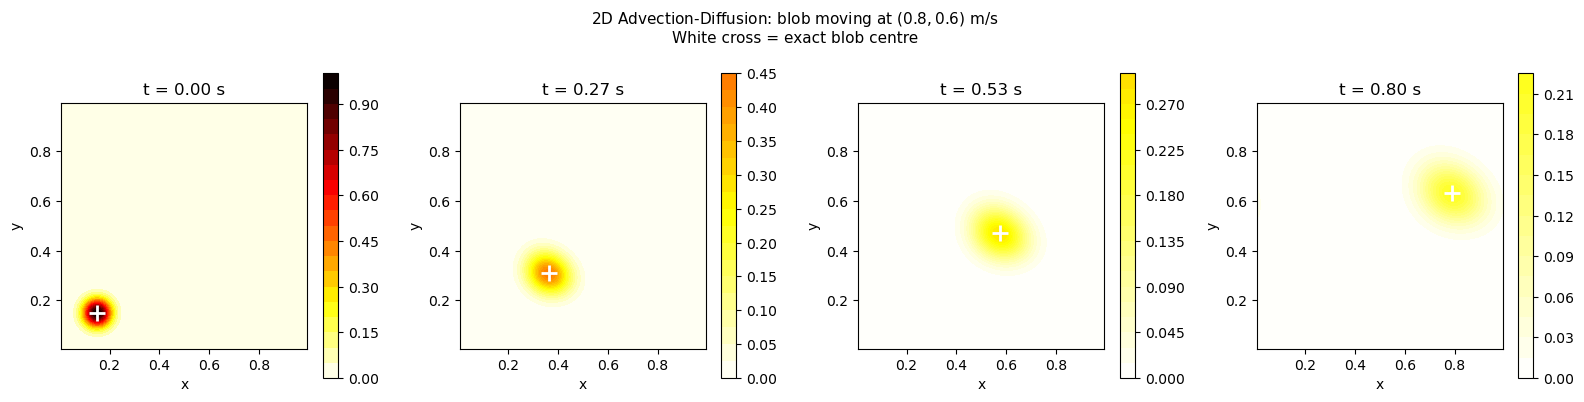

In [2]:
# ── 2D advection-diffusion solver ────────────────────────────────────────────
# Transports a Gaussian blob diagonally across a periodic domain.
# Upwind advection + explicit central diffusion.

# ── Grid ────────────────────────────────────────────────────────────────────
nx, ny = 80, 80
Lx, Ly = 1.0, 1.0
dx = Lx / nx;   dy = Ly / ny
x  = np.linspace(0.5*dx, Lx - 0.5*dx, nx)
y  = np.linspace(0.5*dy, Ly - 0.5*dy, ny)
X, Y = np.meshgrid(x, y)   # shape: (ny, nx)

# ── Flow parameters ──────────────────────────────────────────────────────────
cx    = 0.8    # x-velocity [m/s]
cy    = 0.6    # y-velocity [m/s]
alpha = 2e-4   # diffusivity [m²/s] — small so blob stays sharp

# ── Stable time step (combined CFL + diffusion) ───────────────────────────────
safety = 0.45
dt_cfl  = safety / (abs(cx)/dx + abs(cy)/dy)
dt_diff = safety / (2*alpha*(1/dx**2 + 1/dy**2))
dt = min(dt_cfl, dt_diff)

T     = 0.8
nt    = int(T / dt)

print(f'dt_cfl  = {dt_cfl:.6f} s   (CFL constraint)')
print(f'dt_diff = {dt_diff:.6f} s   (diffusion stability)')
print(f'dt used = {dt:.6f} s   (minimum of the two)')
print(f'nt = {nt} steps')
print(f'CFL_x = {cx*dt/dx:.3f},  CFL_y = {cy*dt/dy:.3f}  ← both must be < 1')

# ── Initial condition: Gaussian blob at (0.15, 0.15) ─────────────────────────
u = np.exp(-((X - 0.15)**2 + (Y - 0.15)**2) / 0.003)

# ── Exact solution: shifts blob to (0.15 + cx*T, 0.15 + cy*T) mod 1.0 ────────
x_exact = (0.15 + cx*T) % Lx
y_exact = (0.15 + cy*T) % Ly
u_exact = np.exp(-((X - x_exact)**2 + (Y - y_exact)**2) / 0.003)

# ── Snapshots ────────────────────────────────────────────────────────────────
snap_times = [0, T/3, 2*T/3, T]
snapshots  = [u.copy()]
snap_steps = {int(t/dt) for t in snap_times[1:]}

for step in range(nt):
    un = u.copy()   # save old values before update

    # ── Upwind advection in x (c_x > 0: backward difference) ────────────────
    u[1:-1, 1:-1] -= dt * cx/dx * (un[1:-1, 1:-1] - un[1:-1, :-2])

    # ── Upwind advection in y (c_y > 0: backward difference) ────────────────
    u[1:-1, 1:-1] -= dt * cy/dy * (un[1:-1, 1:-1] - un[:-2, 1:-1])

    # ── Diffusion (central, explicit) ────────────────────────────────────────
    u[1:-1, 1:-1] += dt * alpha * (
        (un[1:-1, 2:] - 2*un[1:-1, 1:-1] + un[1:-1, :-2]) / dx**2 +
        (un[2:, 1:-1] - 2*un[1:-1, 1:-1] + un[:-2, 1:-1]) / dy**2
    )

    # ── Periodic BCs on all four sides ───────────────────────────────────────
    u[0,  :] = u[-2, :]   # bottom ghost = second-from-top
    u[-1, :] = u[1,  :]   # top ghost    = second-from-bottom
    u[:,  0] = u[:, -2]   # left ghost   = second-from-right
    u[:, -1] = u[:,  1]   # right ghost  = second-from-left

    if (step + 1) in snap_steps:
        snapshots.append(u.copy())

snapshots.append(u.copy())

# ── L2 error vs. exact (pure translation, no diffusion) ──────────────────────
l2_err = np.sqrt(np.mean((u - u_exact)**2))
print(f'\nL2 error vs exact at t={T}: {l2_err:.5f}')
print(f'  → Small error = upwind scheme working correctly')
print(f'  → Residual error from numerical diffusion (upwind is 1st-order)')

# ── Visualise ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, snap, t_label in zip(axes, snapshots, snap_times):
    vmax = snapshots[0].max()
    cf = ax.contourf(X, Y, snap, levels=20, cmap='hot_r', vmin=0, vmax=vmax)
    plt.colorbar(cf, ax=ax)
    ax.set_title(f't = {t_label:.2f} s')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_aspect('equal')
    # Mark exact blob position
    xe = (0.15 + cx*t_label) % Lx
    ye = (0.15 + cy*t_label) % Ly
    ax.plot(xe, ye, 'w+', markersize=12, markeredgewidth=2)

plt.suptitle(f'2D Advection-Diffusion: blob moving at $({cx}, {cy})$ m/s\n'
             f'White cross = exact blob centre', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Boundary Conditions on All Four Sides

### The four walls in 2D

Every 2D domain has four boundaries. Each must be assigned a BC before the simulation starts, and re-applied after every time step update.

```
           Top wall:    u[-1, :]  (j = ny-1)
           ─────────────────────────────────
Left:  │                               │  Right:
u[:,0] │       Interior cells          │  u[:,-1]
       │      u[1:-1, 1:-1]            │
           ─────────────────────────────────
           Bottom wall: u[0, :]   (j = 0)
```

| BC type | Implementation | Physical use |
|---------|---------------|-------------|
| Dirichlet | `u[0, :] = value` | Fixed wall temperature, inlet concentration |
| Neumann (zero-gradient) | `u[0, :] = u[1, :]` | Outlet, insulated wall |
| Periodic | `u[0,:]=u[-2,:]` and `u[-1,:]=u[1,:]` | Infinite channel, turbulence |

### The most common bug

Applying BCs only on the boundary rows but **forgetting the corners**. The corner cell `u[0, 0]` is shared by both the bottom wall and the left wall. For periodic BCs:

```python
# Apply row BCs first, then column BCs — corners get set twice
u[0,  :] = u[-2, :]   # bottom
u[-1, :] = u[1,  :]   # top
u[:,  0] = u[:, -2]   # left  (now corners are also correct)
u[:, -1] = u[:,  1]   # right
```

Order matters: apply row BCs first (they handle the corner values from one direction), then column BCs (which overwrite or confirm the corners from the other direction).

## Summary

| Concept | Key point |
|---------|----------|
| Indexing | `u[j, i]`: j = row = y, i = column = x |
| 2D CFL | $\Delta t \leq 1/(|c_x|/\Delta x + |c_y|/\Delta y)$ — both directions combined |
| 2D diffusion stability | $\Delta t \leq \Delta x^2/(4\alpha)$ for $\Delta x=\Delta y$ — twice as tight as 1D |
| Laplacian stencil | Five-point: centre + four neighbours; same in x and y |
| BCs | Must be applied after every update on all four sides including corners |
| Operator splitting | Apply 1D sweeps alternately — reuses Module 1 code, second-order (Strang) |

---
**Next:** Module 2.2 — Finite Volume Method: why FVM is used in real CFD codes instead of FDM, and how to build a conservative solver from flux balances.

## Exercise

**Predict first, then verify.**

1. Run the solver above with `alpha = 0` (pure advection). Does the blob maintain its shape, or does it smear? What causes the smearing even without physical diffusion? (Hint: modified equation from Module 1.6.)

2. Change `cx = -0.8`, `cy = 0.6` (flow going left and up). Before running: which boundary condition direction and which array slice needs to change for the upwind advection in x? Make the fix and confirm the blob moves in the correct direction.

3. Implement Strang splitting: instead of updating both directions in a single step, apply half a y-step, then a full x-step, then another half y-step. Does the L2 error improve compared to simple (Godunov) splitting?